### Imports:

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Constants and Functions:

In [6]:
# Constants
L = 10  # m
g = 10  # m/s^2
T_small_angle = 2 * np.pi * np.sqrt(L / g)  # Small-angle period

# Equations of motion
def acceleration(theta):
    return -(g / L) * np.sin(theta)

# Euler-Cromer method
def euler_cromer(theta0, omega0, dt, t_max):
    t_values = np.arange(0, t_max, dt)
    theta_values = np.zeros_like(t_values)
    omega_values = np.zeros_like(t_values)
    
    theta_values[0], omega_values[0] = theta0, omega0
    
    for i in range(1, len(t_values)):
        omega_values[i] = omega_values[i - 1] + acceleration(theta_values[i - 1]) * dt
        theta_values[i] = theta_values[i - 1] + omega_values[i] * dt
    
    return t_values, theta_values, omega_values

# Velocity-Verlet method
def velocity_verlet(theta0, omega0, dt, t_max):
    t_values = np.arange(0, t_max, dt)
    theta_values = np.zeros_like(t_values)
    omega_values = np.zeros_like(t_values)
    
    theta_values[0], omega_values[0] = theta0, omega0
    
    for i in range(1, len(t_values)):
        omega_half = omega_values[i - 1] + 0.5 * acceleration(theta_values[i - 1]) * dt
        theta_values[i] = theta_values[i - 1] + omega_half * dt
        omega_values[i] = omega_half + 0.5 * acceleration(theta_values[i]) * dt
    
    return t_values, theta_values, omega_values

# 4th Order Runge-Kutta method
def runge_kutta(theta0, omega0, dt, t_max):
    t_values = np.arange(0, t_max, dt)
    theta_values = np.zeros_like(t_values)
    omega_values = np.zeros_like(t_values)
    
    theta_values[0], omega_values[0] = theta0, omega0
    
    for i in range(1, len(t_values)):
        k1_theta = omega_values[i - 1] * dt
        k1_omega = acceleration(theta_values[i - 1]) * dt
        
        k2_theta = (omega_values[i - 1] + 0.5 * k1_omega) * dt
        k2_omega = acceleration(theta_values[i - 1] + 0.5 * k1_theta) * dt
        
        k3_theta = (omega_values[i - 1] + 0.5 * k2_omega) * dt
        k3_omega = acceleration(theta_values[i - 1] + 0.5 * k2_theta) * dt
        
        k4_theta = (omega_values[i - 1] + k3_omega) * dt
        k4_omega = acceleration(theta_values[i - 1] + k3_theta) * dt
        
        theta_values[i] = theta_values[i - 1] + (k1_theta + 2 * k2_theta + 2 * k3_theta + k4_theta) / 6
        omega_values[i] = omega_values[i - 1] + (k1_omega + 2 * k2_omega + 2 * k3_omega + k4_omega) / 6
    
    return t_values, theta_values, omega_values

# Energy calculation
def energy(theta, omega):
    return 0.5 * L**2 * omega**2 - g * L * np.cos(theta)

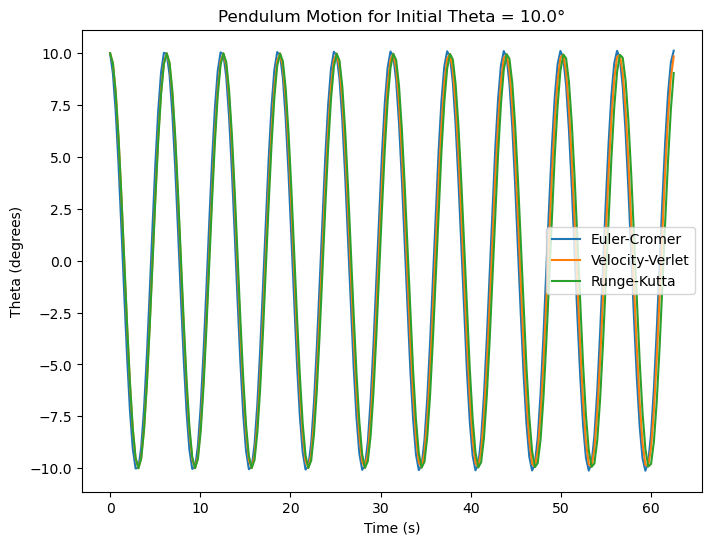

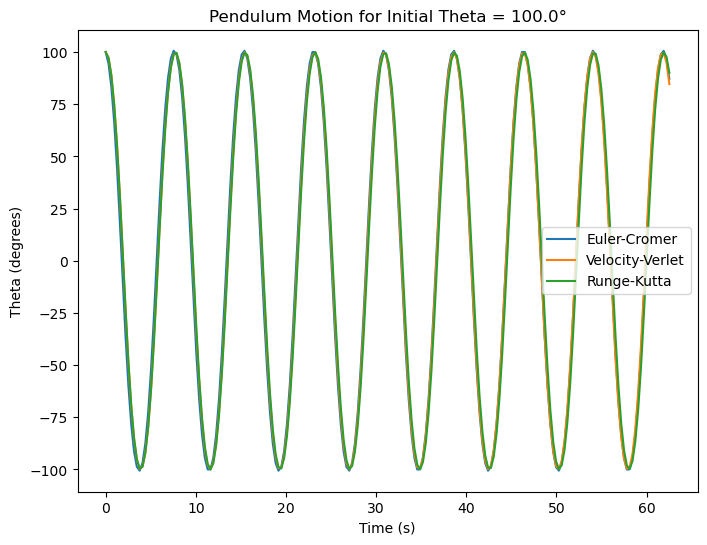

In [10]:
# Parameters
theta0_list = [np.radians(10.), np.radians(100.)]
dt = T_small_angle / 20.  # Ensuring at least 20 steps per period
t_max = 10 * T_small_angle

# Run and plot results
methods = {"Euler-Cromer": euler_cromer, "Velocity-Verlet": velocity_verlet, "Runge-Kutta": runge_kutta}

for theta0 in theta0_list:
    plt.figure(figsize=(8, 6))
    
    for method_name, method in methods.items():
        t_vals, theta_vals, omega_vals = method(theta0, 0.0, dt, t_max)
        plt.plot(t_vals, np.degrees(theta_vals), label=method_name)
        print(' ')
    
    plt.xlabel("Time (s)")
    plt.ylabel("Theta (degrees)")
    plt.title(f"Pendulum Motion for Initial Theta = {np.degrees(theta0)}°")
    plt.legend()
    plt.show()

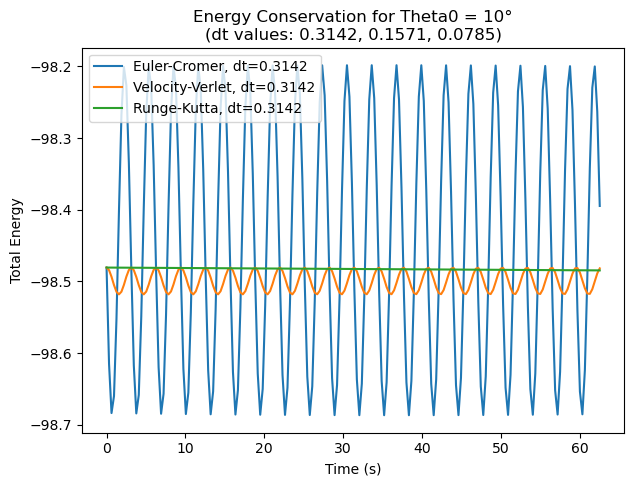

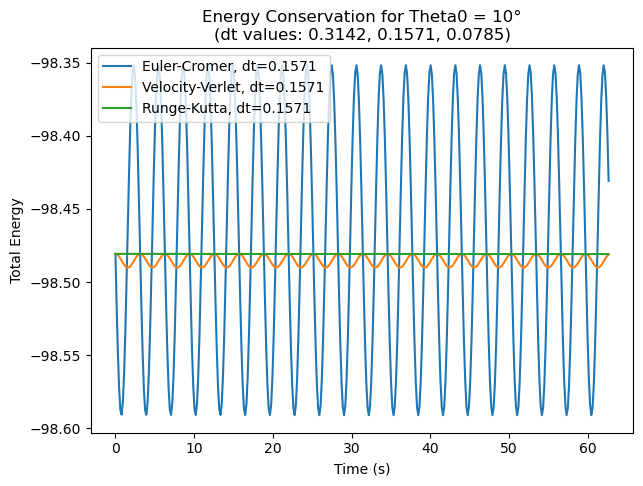

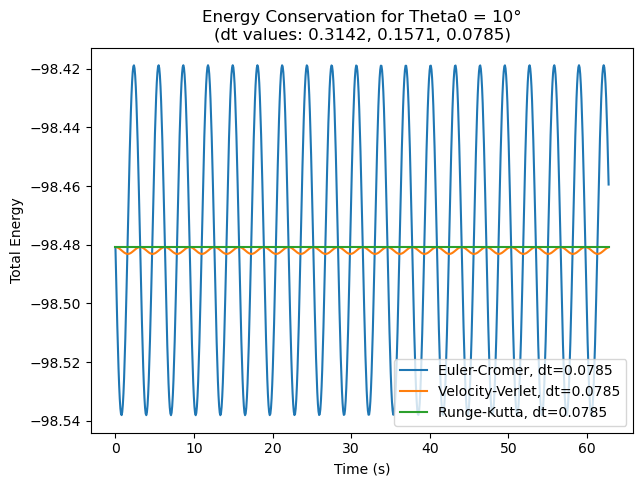

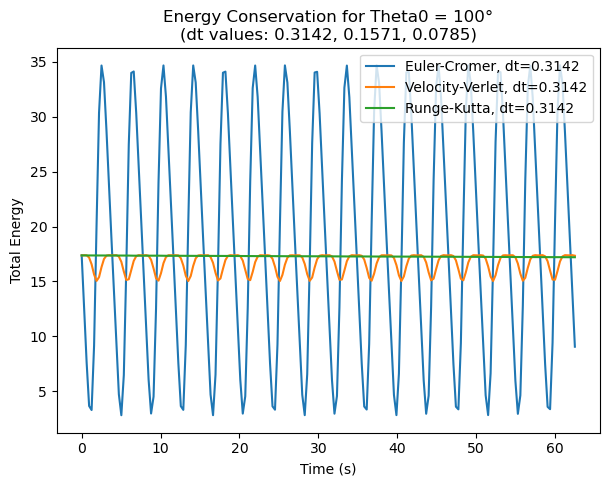

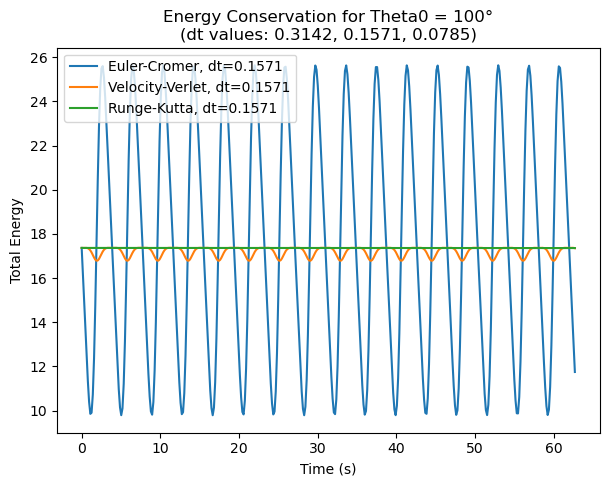

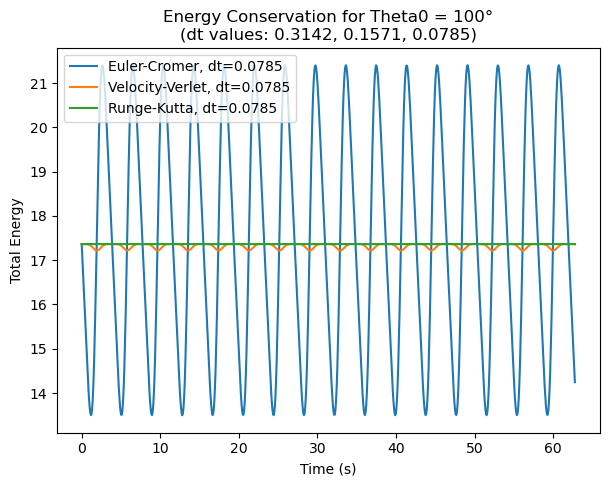

In [41]:
for theta_label, theta0 in theta_values.items():
    dt_labels = ", ".join([f"{dt:.4f}" for dt in dt_values])  # Formatting dt values for the title
    
    for dt in dt_values:
        plt.figure(figsize=(7, 5))
        
        for method_name, method in methods.items():
            t_vals, theta_vals, omega_vals = method(theta0, 0, dt, t_max)
            energy_vals = energy(theta_vals, omega_vals)
            plt.plot(t_vals, energy_vals, label=f"{method_name}, dt={dt:.4f}")
            print(' ')
        
        plt.xlabel("Time (s)")
        plt.ylabel("Total Energy")
        plt.title(f"Energy Conservation for Theta0 = {theta_label}\n(dt values: {dt_labels})")
        plt.legend()
        plt.show()

### To be fair, I am not sure if I did something incorrect, so I decided to redo the whole thing.
### ᕦ(ò_óˇ)ᕤ Time for me to be upsetti spaghetti.
### (ﾉ◕ヮ◕)ﾉ*:･ﾟ✧ Spaghetti sounds great now.

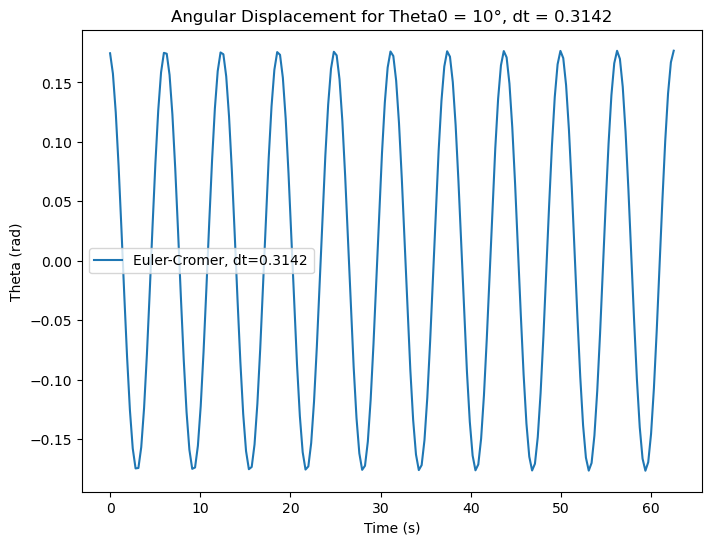

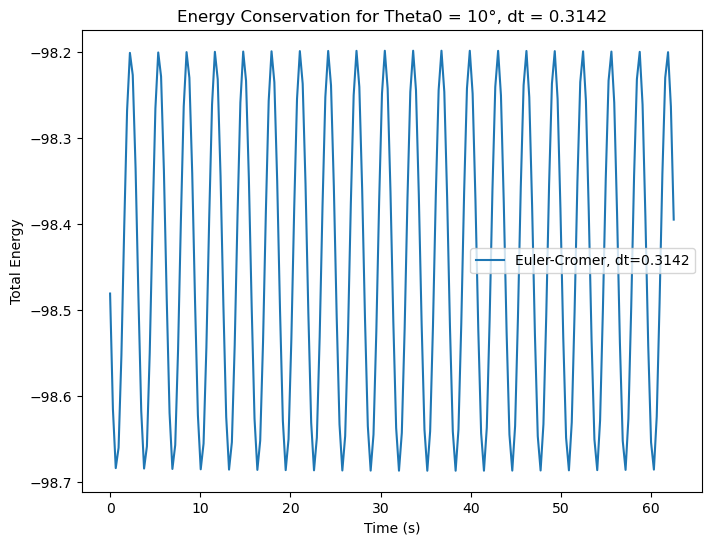

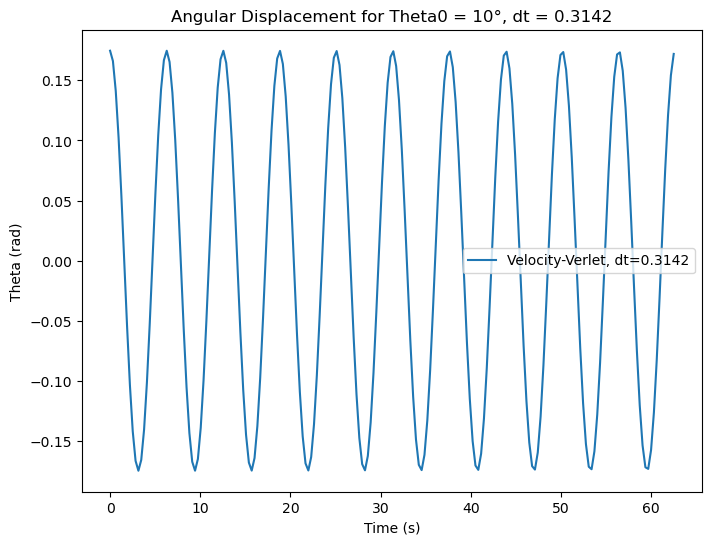

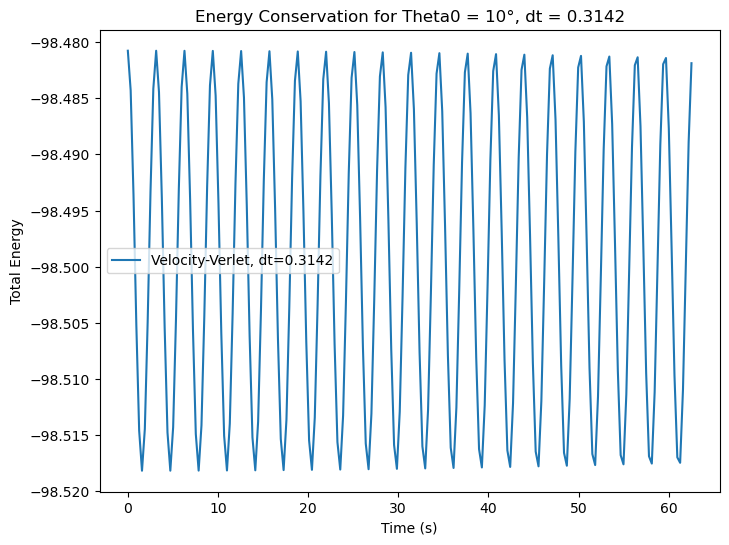

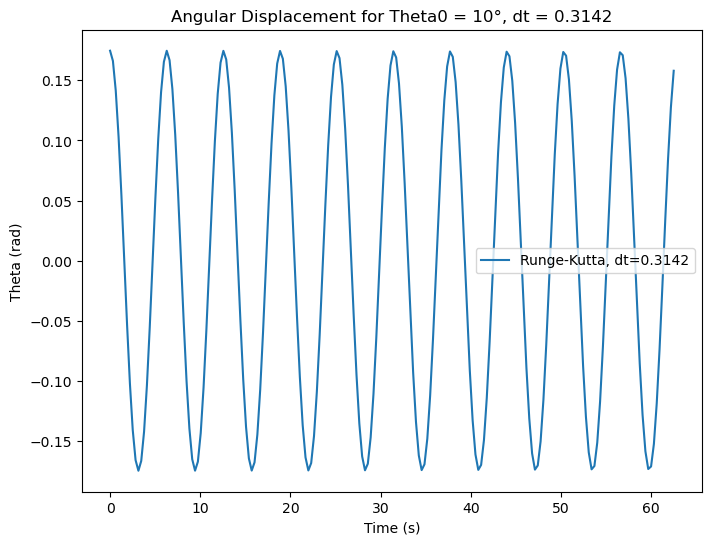

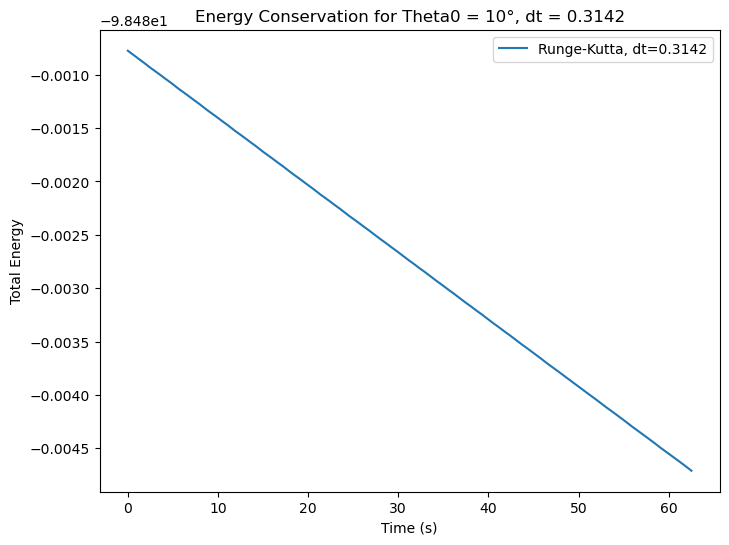

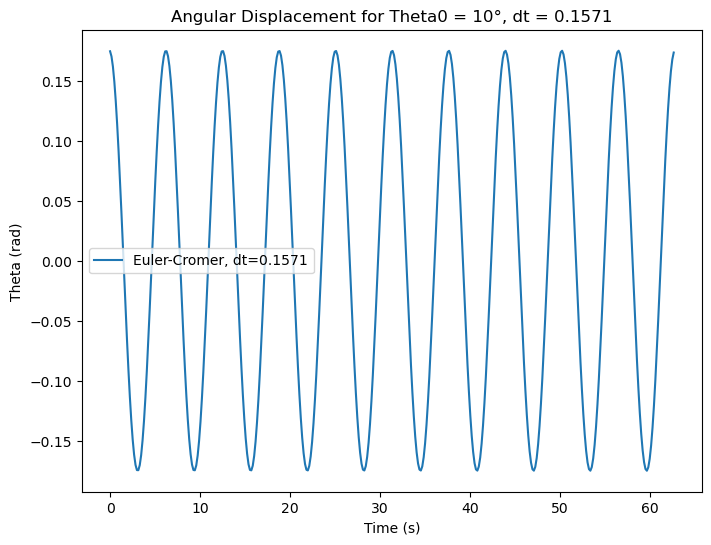

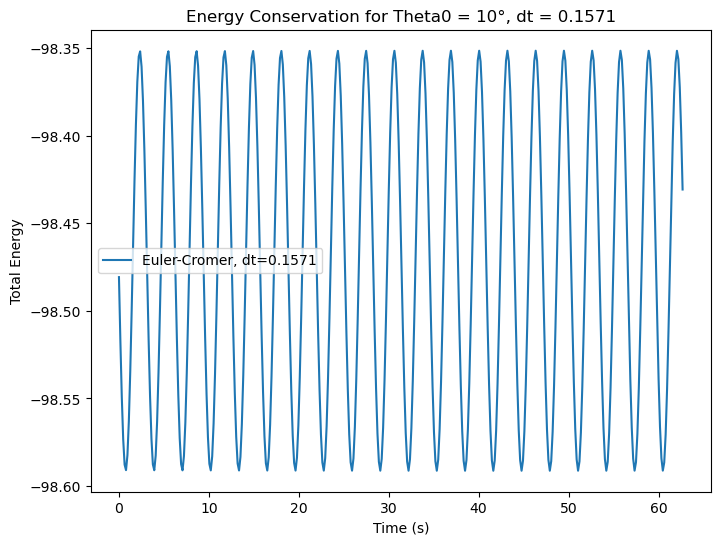

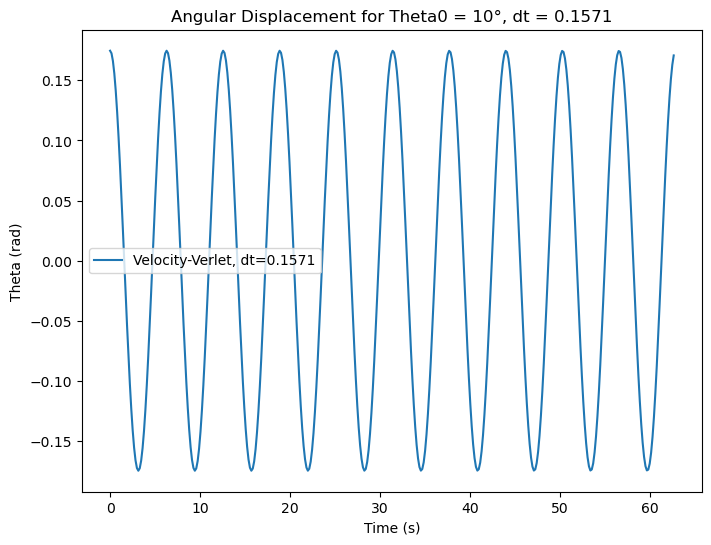

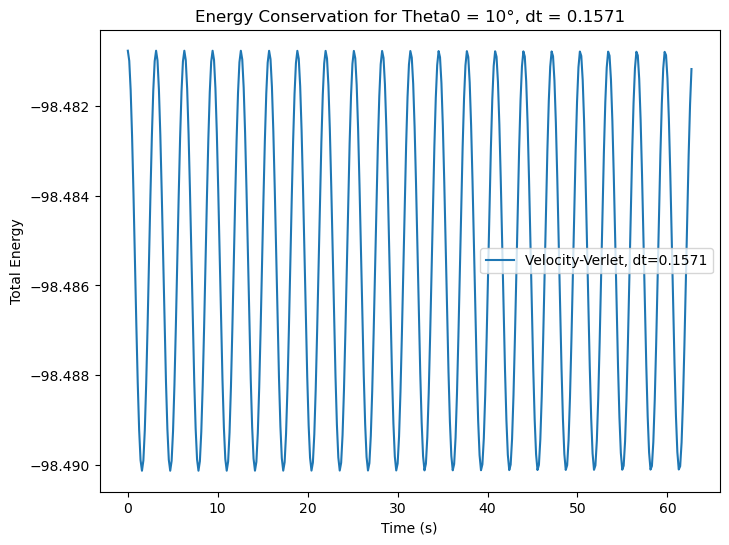

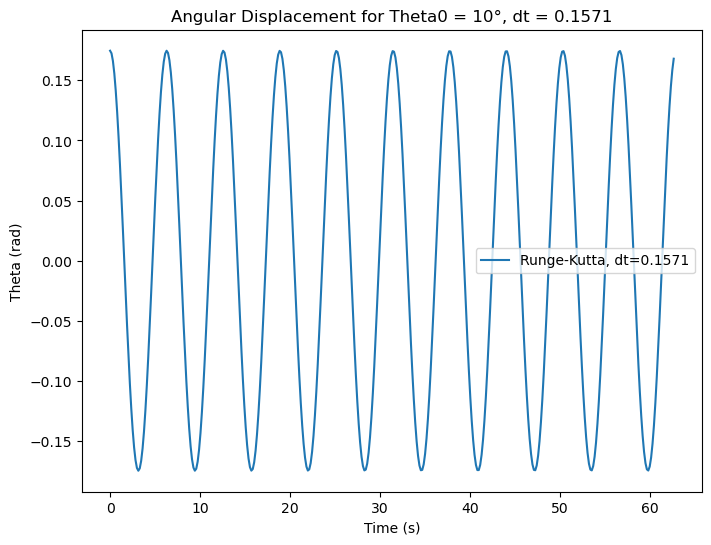

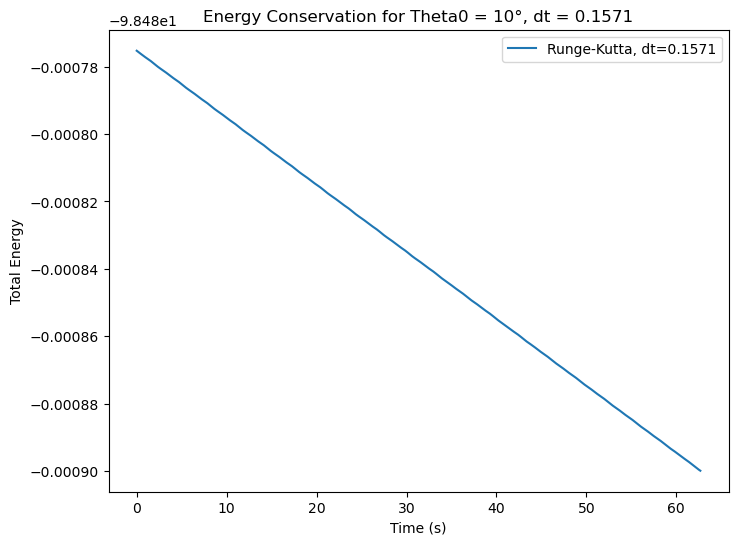

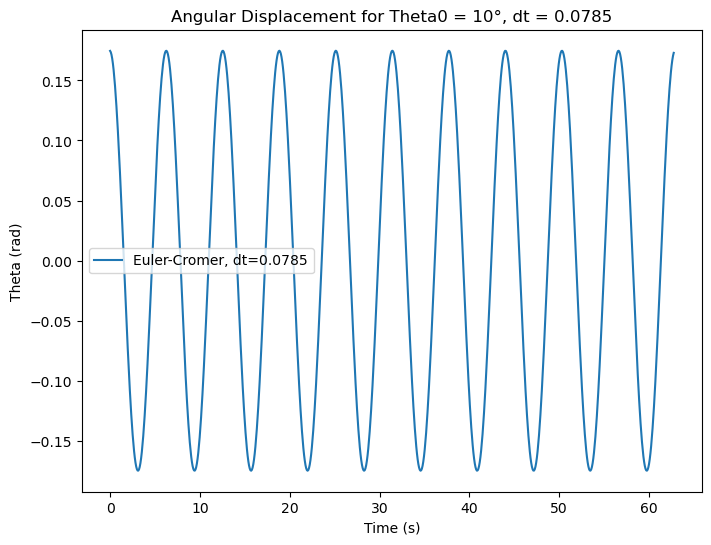

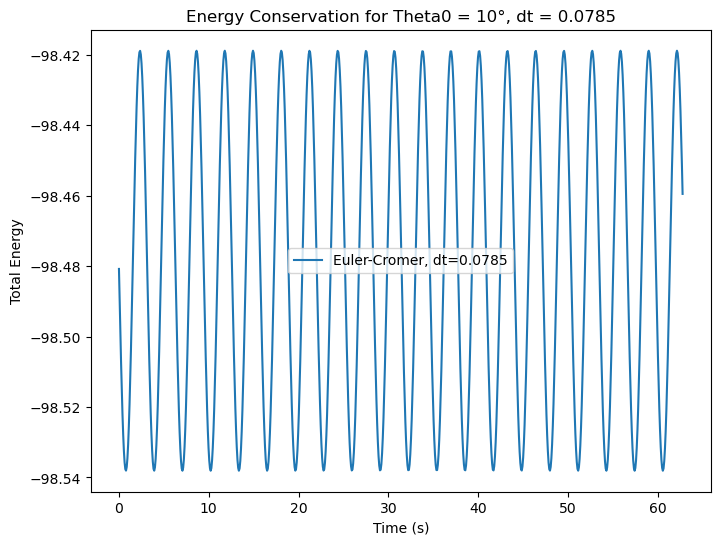

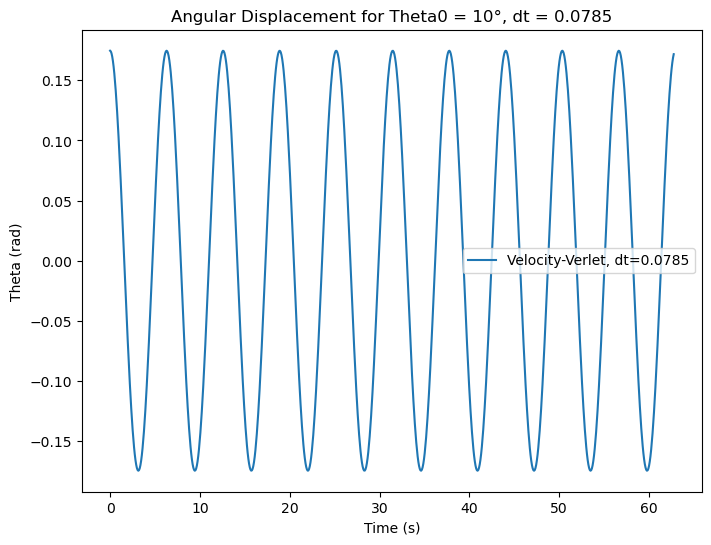

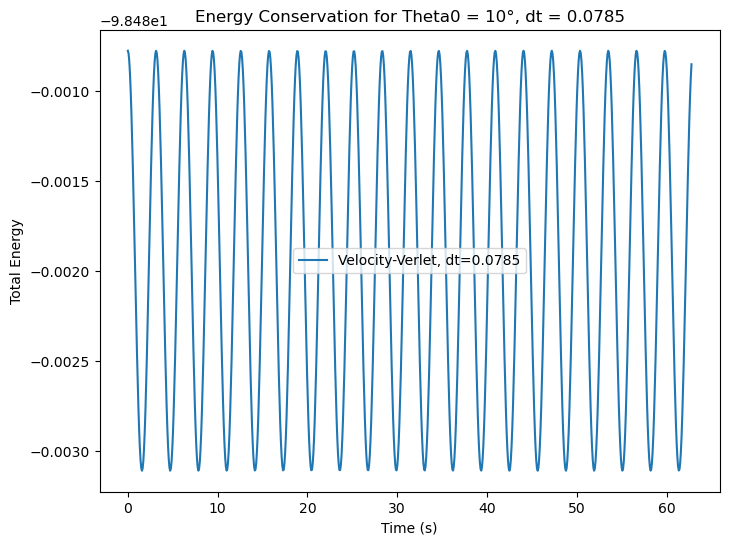

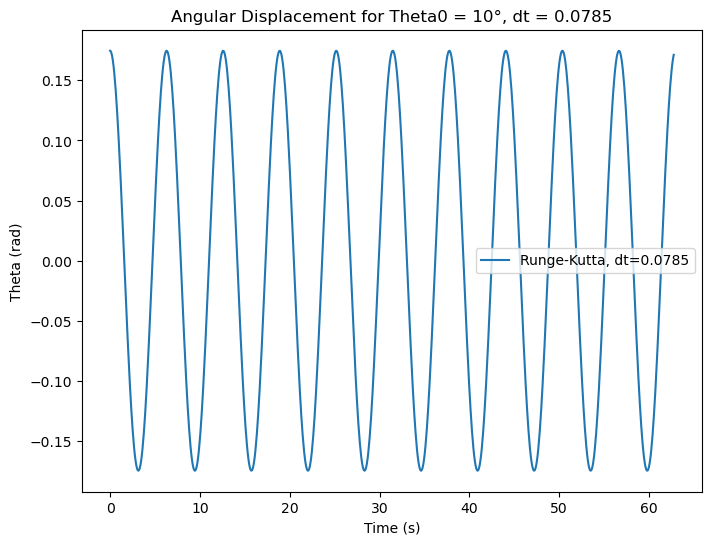

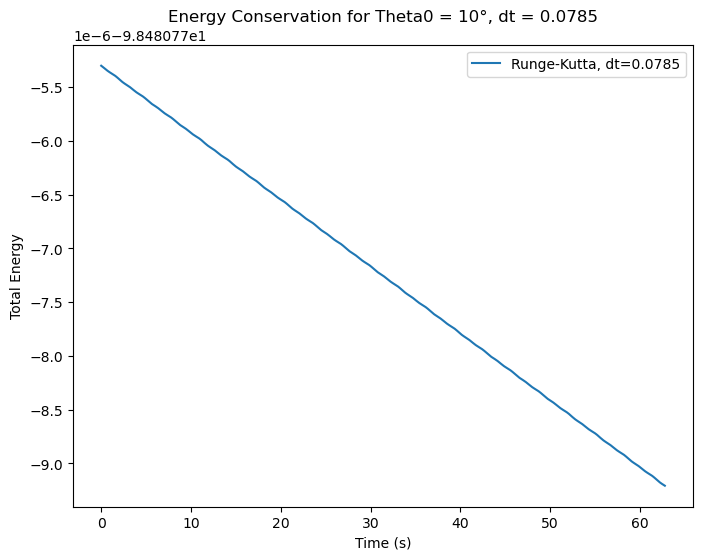

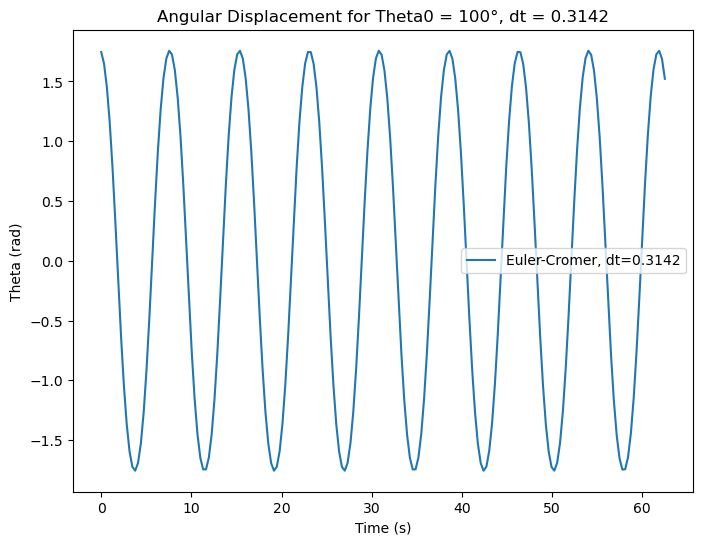

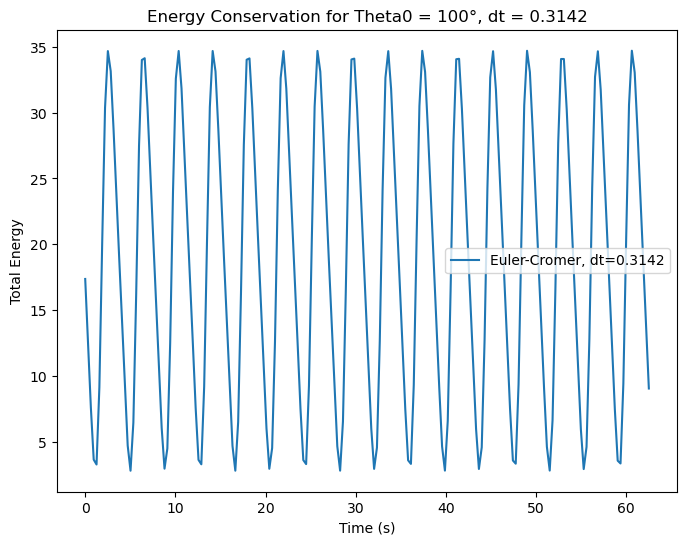

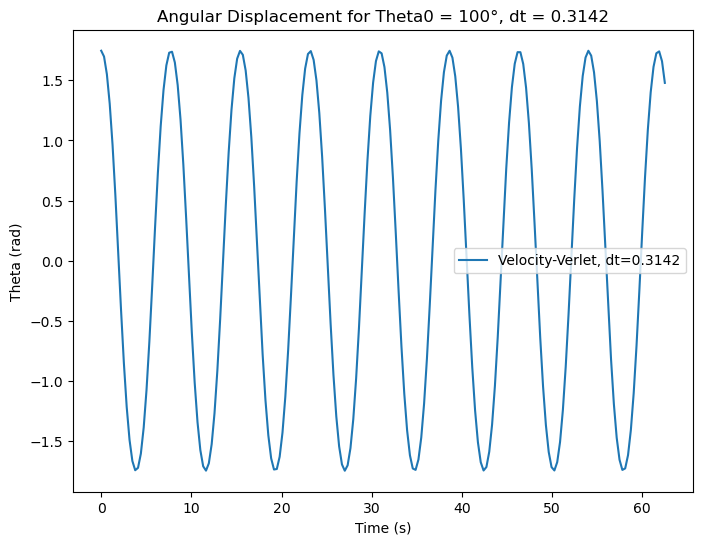

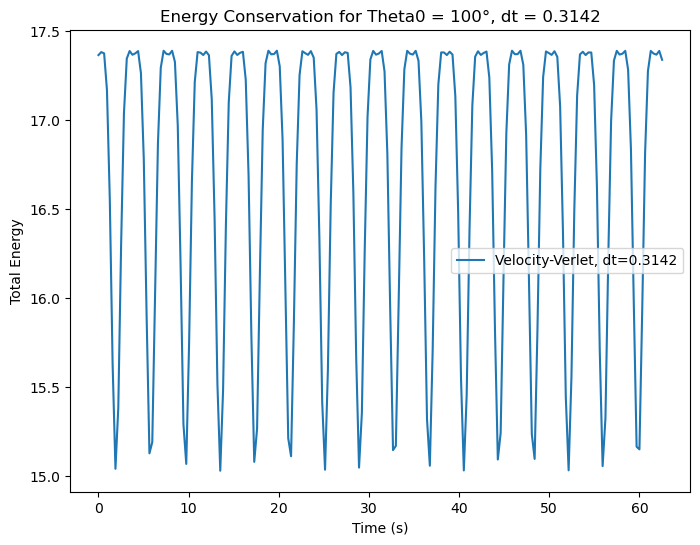

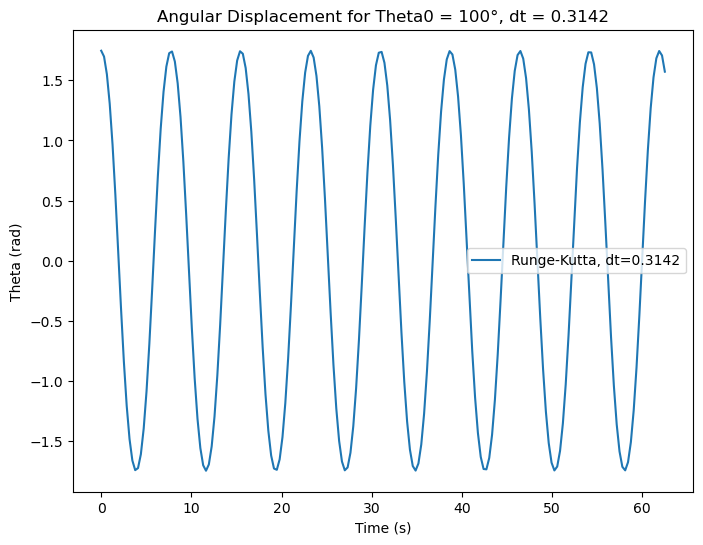

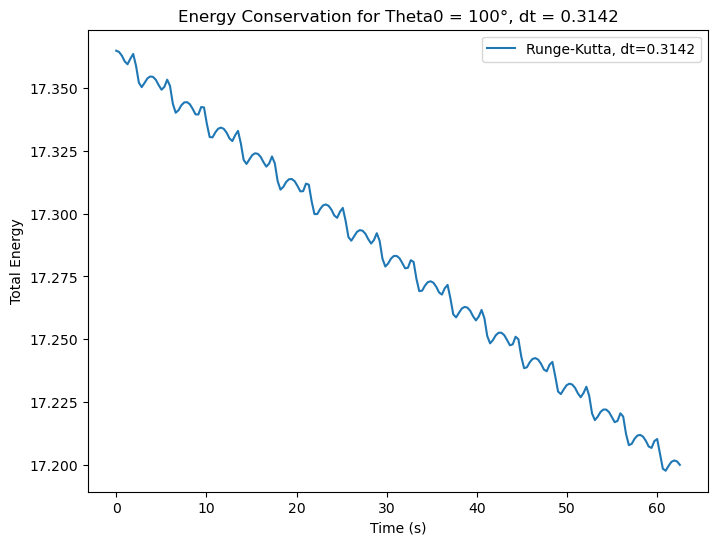

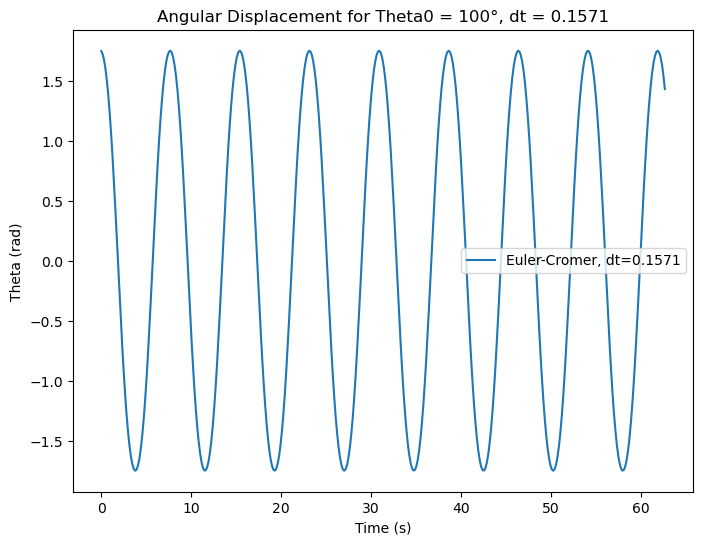

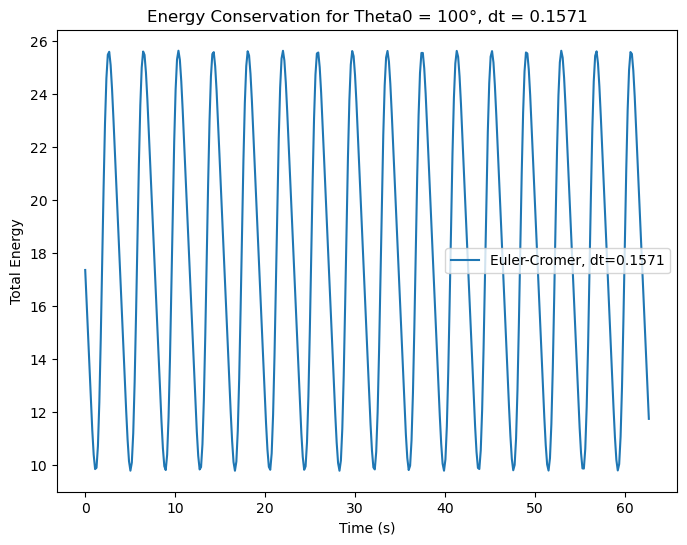

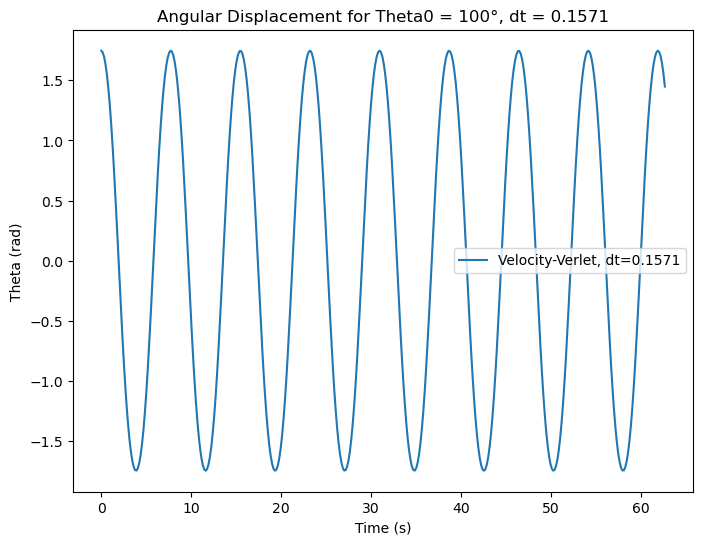

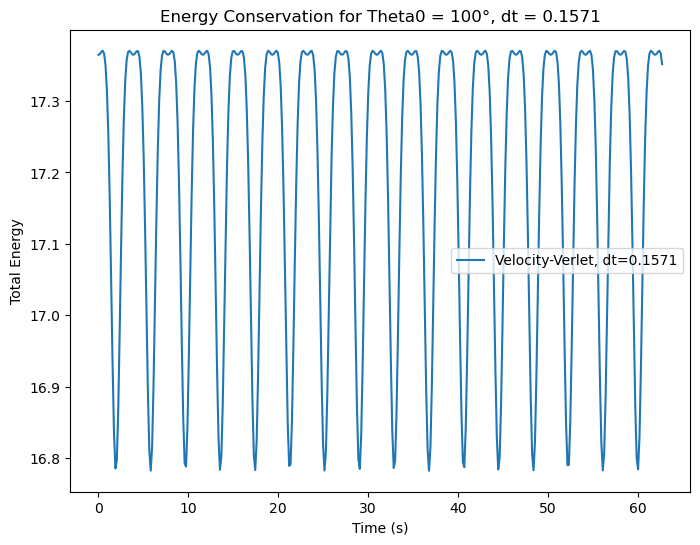

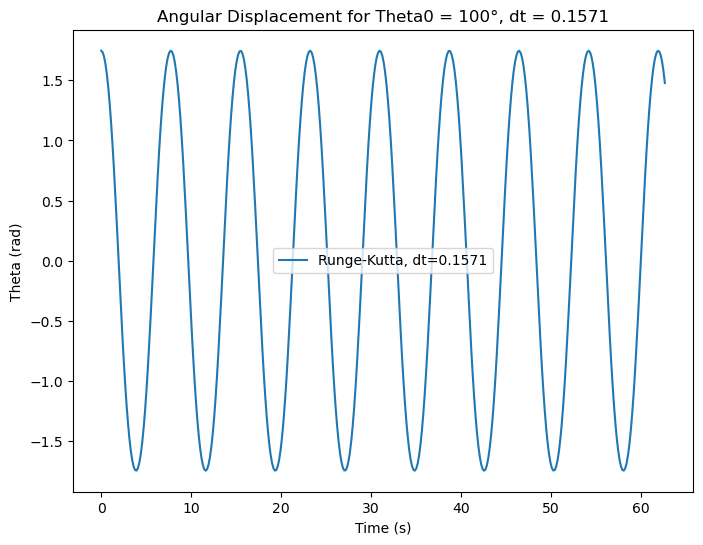

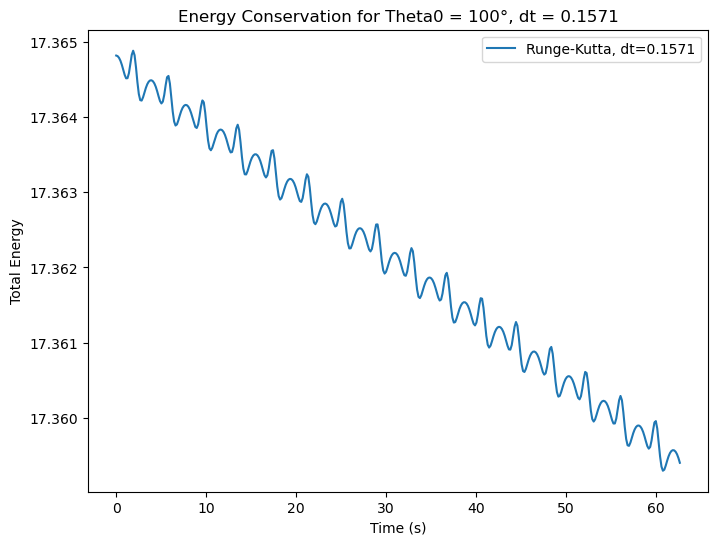

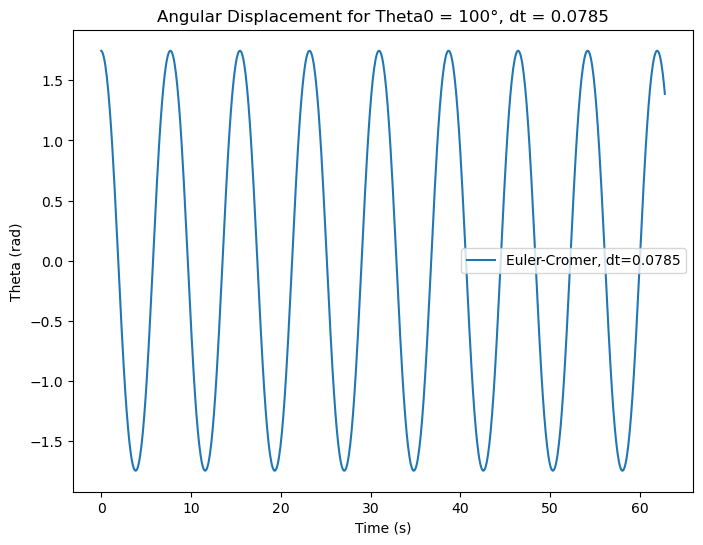

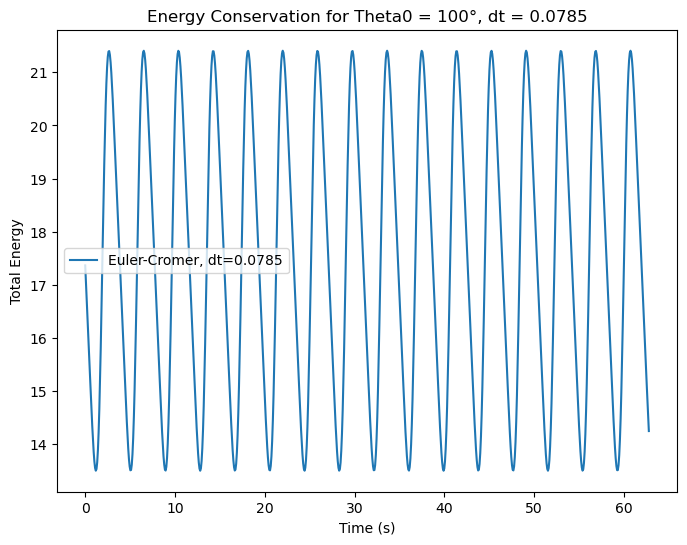

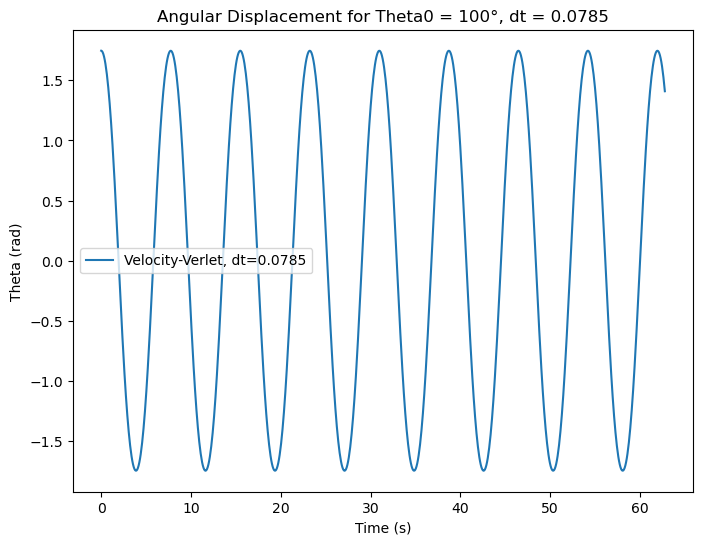

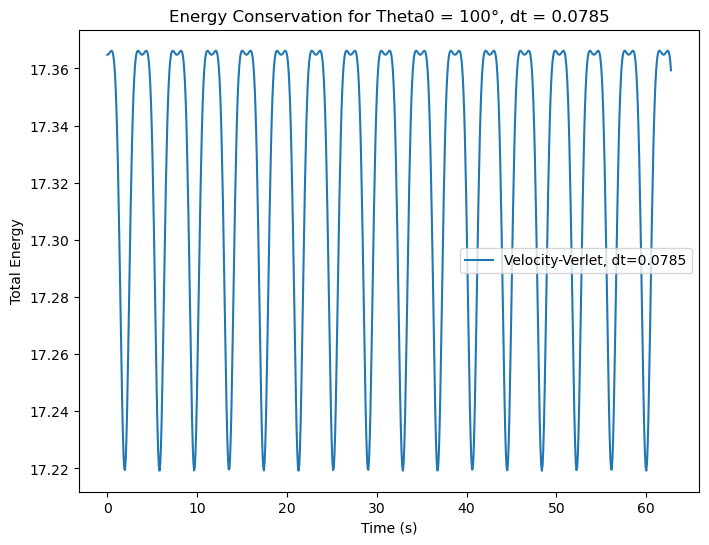

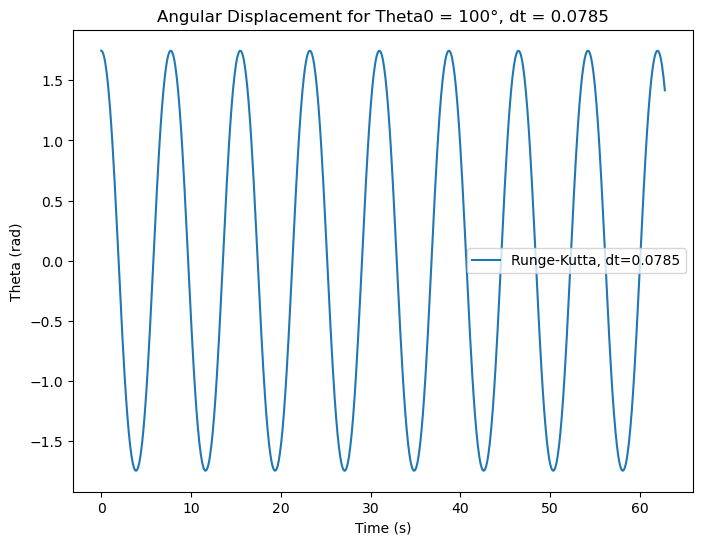

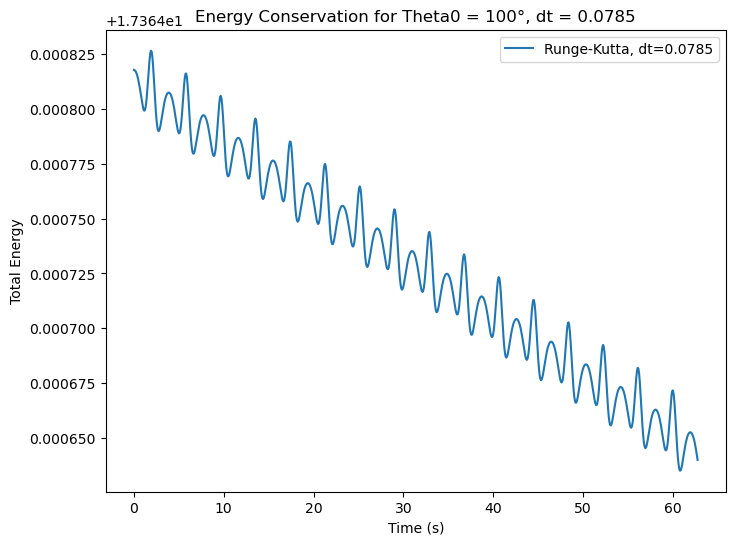

In [18]:
# Constants
L = 10  # m
g = 10  # m/s^2
t_max = 10 * (2 * np.pi * np.sqrt(L / g))  # Run for 10 periods

# Equations of Motion
def acceleration(theta):
    return - (g / L) * np.sin(theta)

# Euler-Cromer Method
def euler_cromer(theta0, omega0, dt, t_max):
    t_vals = np.arange(0, t_max, dt)
    theta_vals = np.zeros_like(t_vals)
    omega_vals = np.zeros_like(t_vals)
    
    theta_vals[0] = theta0
    omega_vals[0] = omega0

    for i in range(1, len(t_vals)):
        omega_vals[i] = omega_vals[i-1] + acceleration(theta_vals[i-1]) * dt
        theta_vals[i] = theta_vals[i-1] + omega_vals[i] * dt
    
    return t_vals, theta_vals, omega_vals

# Velocity-Verlet Method
def velocity_verlet(theta0, omega0, dt, t_max):
    t_vals = np.arange(0, t_max, dt)
    theta_vals = np.zeros_like(t_vals)
    omega_vals = np.zeros_like(t_vals)
    
    theta_vals[0] = theta0
    omega_vals[0] = omega0

    for i in range(1, len(t_vals)):
        a_old = acceleration(theta_vals[i-1])
        theta_vals[i] = theta_vals[i-1] + omega_vals[i-1] * dt + 0.5 * a_old * dt**2
        a_new = acceleration(theta_vals[i])
        omega_vals[i] = omega_vals[i-1] + 0.5 * (a_old + a_new) * dt
    
    return t_vals, theta_vals, omega_vals

# 4th Order Runge-Kutta Method
def runge_kutta(theta0, omega0, dt, t_max):
    t_vals = np.arange(0, t_max, dt)
    theta_vals = np.zeros_like(t_vals)
    omega_vals = np.zeros_like(t_vals)
    
    theta_vals[0] = theta0
    omega_vals[0] = omega0

    for i in range(1, len(t_vals)):
        k1_theta = dt * omega_vals[i-1]
        k1_omega = dt * acceleration(theta_vals[i-1])
        
        k2_theta = dt * (omega_vals[i-1] + 0.5 * k1_omega)
        k2_omega = dt * acceleration(theta_vals[i-1] + 0.5 * k1_theta)
        
        k3_theta = dt * (omega_vals[i-1] + 0.5 * k2_omega)
        k3_omega = dt * acceleration(theta_vals[i-1] + 0.5 * k2_theta)
        
        k4_theta = dt * (omega_vals[i-1] + k3_omega)
        k4_omega = dt * acceleration(theta_vals[i-1] + k3_theta)
        
        theta_vals[i] = theta_vals[i-1] + (k1_theta + 2*k2_theta + 2*k3_theta + k4_theta) / 6
        omega_vals[i] = omega_vals[i-1] + (k1_omega + 2*k2_omega + 2*k3_omega + k4_omega) / 6
    
    return t_vals, theta_vals, omega_vals

# Energy function (without mass)
def energy(theta_vals, omega_vals):
    kinetic = 0.5 * (L**2) * omega_vals**2  # (1/2) L² ω²
    potential = -g * L * np.cos(theta_vals)  # -gL cos(θ)
    return kinetic + potential

# Small-angle approximation period
T_small_angle = 2 * np.pi * np.sqrt(L / g)

# Initial conditions
theta_values = {"10°": np.radians(10), "100°": np.radians(100)}
dt_values = [T_small_angle / 20, T_small_angle / 40, T_small_angle / 80]

methods = {
    "Euler-Cromer": euler_cromer,
    "Velocity-Verlet": velocity_verlet,
    "Runge-Kutta": runge_kutta
}

# Separate plots for each (theta0, dt) combination
for theta_label, theta0 in theta_values.items():
    for dt in dt_values:
        for method_name, method in methods.items():
            t_vals, theta_vals, omega_vals = method(theta0, 0, dt, t_max)
            energy_vals = energy(theta_vals, omega_vals)
            
            # Plot theta vs time separately
            plt.figure(figsize=(8, 6))
            plt.plot(t_vals, theta_vals, label=f"{method_name}, dt={dt:.4f}")
            plt.xlabel("Time (s)")
            plt.ylabel("Theta (rad)")
            plt.title(f"Angular Displacement for Theta0 = {theta_label}, dt = {dt:.4f}")
            plt.legend()
            plt.show()
            
            # Plot energy vs time separately
            plt.figure(figsize=(8, 6))
            plt.plot(t_vals, energy_vals, label=f"{method_name}, dt={dt:.4f}")
            plt.xlabel("Time (s)")
            plt.ylabel("Total Energy")
            plt.title(f"Energy Conservation for Theta0 = {theta_label}, dt = {dt:.4f}")
            plt.legend()
            plt.show()


#### So, what was done above, does look better but ಠ╭╮ಠ Is it right.